# Kinema Pipeline Demo

End-to-end walkthrough of what's built so far:

1. **Video I/O** — probe metadata, sample frames
2. **Pose extraction** — MediaPipe → Parquet
3. **Keypoints exploration** — schema, distributions, visibility
4. **Skeleton visualization** — overlay on sample frames
5. **Trajectory** — joint positions over time

In [1]:
import sys
sys.path.insert(0, '../src')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import mediapipe as mp

from kinema.io.video import probe_video, iter_frames
from kinema.io.keypoints import LANDMARK_NAMES, read_keypoints
from kinema.pose.extract import extract_pose

DATA_DIR = Path('../data/raw')
OUT_DIR  = Path('../data/processed')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# MediaPipe skeleton edge list (landmark index pairs)
POSE_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),
    (9,10),(11,12),(11,13),(13,15),(15,17),(15,19),(15,21),(17,19),
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),
    (11,23),(12,24),(23,24),(23,25),(24,26),
    (25,27),(26,28),(27,29),(28,30),(29,31),(30,32),(27,31),(28,32),
]

print('Setup complete.')

Setup complete.


## 1. Video inventory

In [2]:
videos = sorted(DATA_DIR.glob('*.mp4'))
rows = []
for v in videos:
    m = probe_video(v)
    rows.append({
        'file': v.name,
        'width': m.width,
        'height': m.height,
        'fps': m.fps,
        'frames': m.frame_count,
        'duration_s': round(m.duration_sec, 1),
        'rotation': m.rotation_degrees,
    })

inv = pd.DataFrame(rows)
inv

,file,width,height,fps,frames,duration_s,rotation
0,VID-20260528-WA0043.mp4,478,850,30.0,1248,41.6,0
1,VID-20260528-WA0044.mp4,478,850,30.0,593,19.8,0
2,VID-20260528-WA0045.mp4,478,850,30.0,1059,35.3,0
3,VID-20260528-WA0046.mp4,478,850,30.0,902,30.1,0
4,VID-20260528-WA0047.mp4,478,850,30.0,1429,47.7,0
5,VID-20260528-WA0048.mp4,478,850,30.0,1107,36.9,0
6,WhatsApp Video 2026-05-28 at 11.58.59.mp4,464,832,60.0,2180,36.4,0


## 2. Sample frames — pick a clip

Using the shortest clip for speed. Change `VIDEO_PATH` to try others.

In [3]:
# Pick shortest clip
shortest = min(videos, key=lambda p: probe_video(p).duration_sec)
VIDEO_PATH = shortest
meta = probe_video(VIDEO_PATH)

print(f'Selected: {VIDEO_PATH.name}')
print(f'  {meta.width}x{meta.height}  {meta.fps:.0f} fps  {meta.duration_sec:.1f}s  '
      f'{meta.frame_count} frames  rotation={meta.rotation_degrees}°')

Selected: VID-20260528-WA0044.mp4
  478x850  30 fps  19.8s  593 frames  rotation=0°


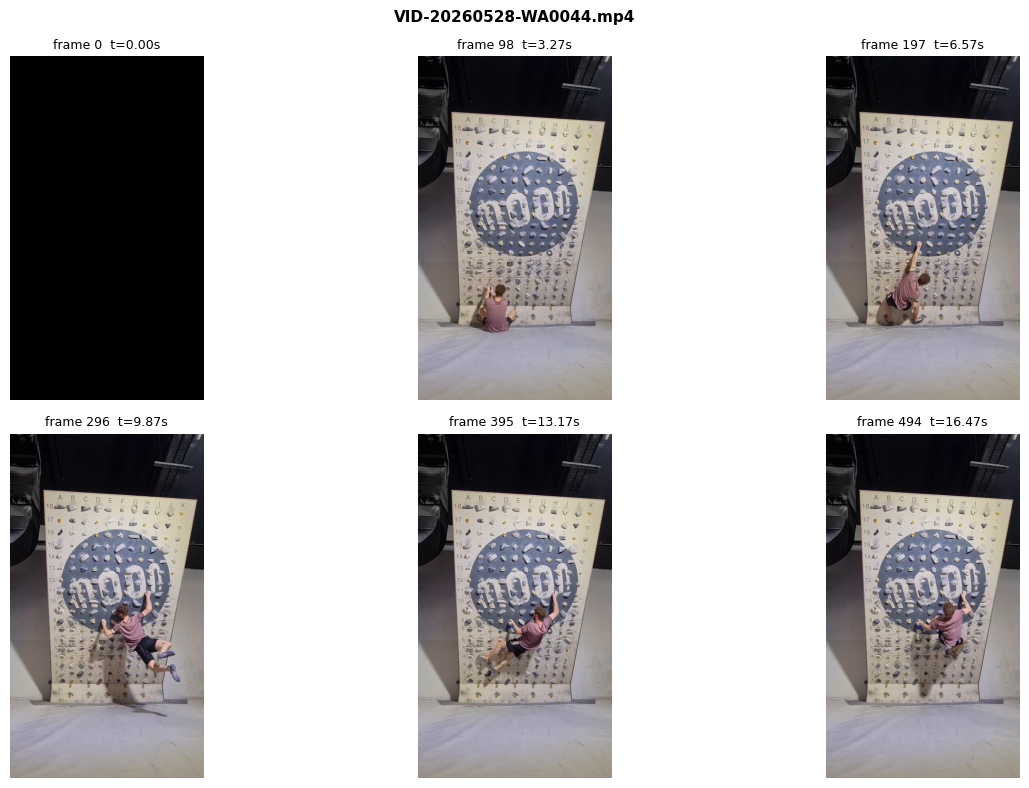

In [4]:
# Sample 6 evenly-spaced frames
N_SAMPLES = 6
sample_indices = set(
    int(i * meta.frame_count / N_SAMPLES) for i in range(N_SAMPLES)
)

sampled = {}
for idx, ts, frame in iter_frames(VIDEO_PATH):
    if idx in sample_indices:
        sampled[idx] = (ts, frame)
    if len(sampled) == N_SAMPLES:
        break

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (fidx, (ts, frame)) in zip(axes.flat, sorted(sampled.items())):
    ax.imshow(frame)
    ax.set_title(f'frame {fidx}  t={ts:.2f}s', fontsize=9)
    ax.axis('off')
plt.suptitle(VIDEO_PATH.name, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Pose extraction → Parquet

Run MediaPipe Pose on every frame. Lite model (~8 MB, downloads once to `~/.cache/kinema/models/`).

In [5]:
import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')

parquet_path = OUT_DIR / (VIDEO_PATH.stem + '_keypoints.parquet')

stats = extract_pose(
    VIDEO_PATH,
    parquet_path,
    model_complexity=0,          # lite — fast enough for a demo
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)

print(f'\nExtraction stats:')
print(f'  frames processed  : {stats.frame_count}')
print(f'  frames with pose  : {stats.frames_with_pose}')
print(f'  detection rate    : {stats.frames_with_pose/stats.frame_count:.1%}')
print(f'  mean visibility   : {stats.mean_visibility:.3f}')
print(f'  wall time         : {stats.wall_time_sec:.1f}s  ({stats.frame_count/stats.wall_time_sec:.1f} fps)')

INFO kinema.pose.extract: Extracting pose from VID-20260528-WA0044.mp4: 593 frames at 30.0 fps
I0000 00:00:1779960395.702429 1465856 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1779960395.888739 1465913 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 595.58.03), renderer: NVIDIA GeForce RTX 3070 Ti/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779960395.934469 1465860 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779960395.965748 1465881 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
VID-20260528-WA0044.mp4: 100%|██████████| 593/593 [00:11<00:00, 52.76frame/s]
INFO kinema.pose.extract: Extraction complete: 586/593 frames with pose, 0.814 mean visibility, 11.8s



Extraction stats:
  frames processed  : 593
  frames with pose  : 586
  detection rate    : 98.8%
  mean visibility   : 0.814
  wall time         : 11.8s  (50.1 fps)


## 4. Explore the Parquet

In [6]:
kp = read_keypoints(parquet_path)

print(f'Shape : {kp.shape}  ({len(kp)//33} frames × 33 landmarks)')
print(f'Dtypes:')
print(kp.dtypes.to_string())
print()
kp.head(10)

Shape : (19569, 8)  (593 frames × 33 landmarks)
Dtypes:
frame_idx           int32
timestamp_ms        int64
landmark_id          int8
landmark_name    category
x                 float32
y                 float32
z                 float32
visibility        float32



,frame_idx,timestamp_ms,landmark_id,landmark_name,x,y,z,visibility
0,0,0,0,NOSE,NaN,NaN,NaN,0.0
1,0,0,1,LEFT_EYE_INNER,NaN,NaN,NaN,0.0
2,0,0,2,LEFT_EYE,NaN,NaN,NaN,0.0
3,0,0,3,LEFT_EYE_OUTER,NaN,NaN,NaN,0.0
4,0,0,4,RIGHT_EYE_INNER,NaN,NaN,NaN,0.0
5,0,0,5,RIGHT_EYE,NaN,NaN,NaN,0.0
6,0,0,6,RIGHT_EYE_OUTER,NaN,NaN,NaN,0.0
7,0,0,7,LEFT_EAR,NaN,NaN,NaN,0.0
8,0,0,8,RIGHT_EAR,NaN,NaN,NaN,0.0
9,0,0,9,MOUTH_LEFT,NaN,NaN,NaN,0.0


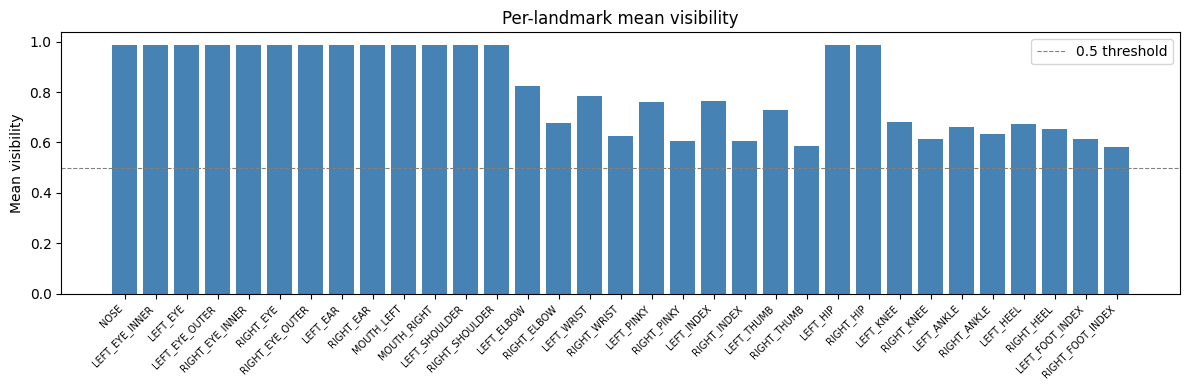

In [7]:
# Per-landmark mean visibility across all frames
vis_by_lm = (
    kp.groupby('landmark_name', observed=True)['visibility']
    .mean()
    .reindex(LANDMARK_NAMES)   # keep canonical order
)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['steelblue' if v > 0.5 else 'tomato' for v in vis_by_lm]
ax.bar(range(len(vis_by_lm)), vis_by_lm.values, color=colors)
ax.set_xticks(range(len(vis_by_lm)))
ax.set_xticklabels(vis_by_lm.index, rotation=45, ha='right', fontsize=7)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='0.5 threshold')
ax.set_ylabel('Mean visibility')
ax.set_title('Per-landmark mean visibility')
ax.legend()
plt.tight_layout()
plt.show()

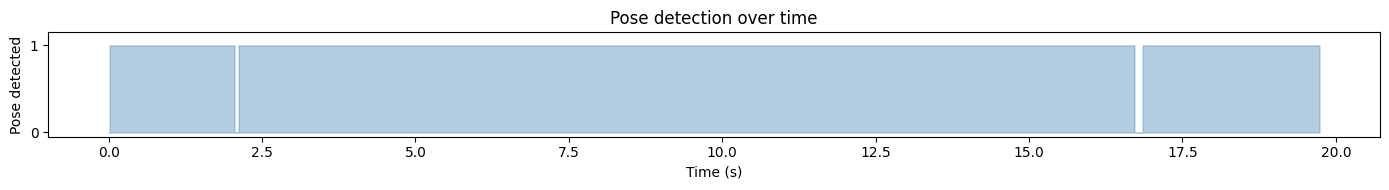

In [8]:
# Detection rate per frame (1 = pose found, 0 = no pose)
detected = (
    kp.groupby('frame_idx')['visibility']
    .max()
    .gt(0)
    .astype(int)
)
timestamps = kp.groupby('frame_idx')['timestamp_ms'].first() / 1000.0

fig, ax = plt.subplots(figsize=(14, 2))
ax.fill_between(timestamps, detected, alpha=0.4, color='steelblue', step='mid')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Pose detected')
ax.set_title('Pose detection over time')
ax.set_ylim(-0.05, 1.15)
ax.set_yticks([0, 1])
plt.tight_layout()
plt.show()

## 5. Skeleton overlay on sample frames

Draw the 33 landmarks and 35 skeleton edges on frames where pose was detected.

586 frames with pose detected


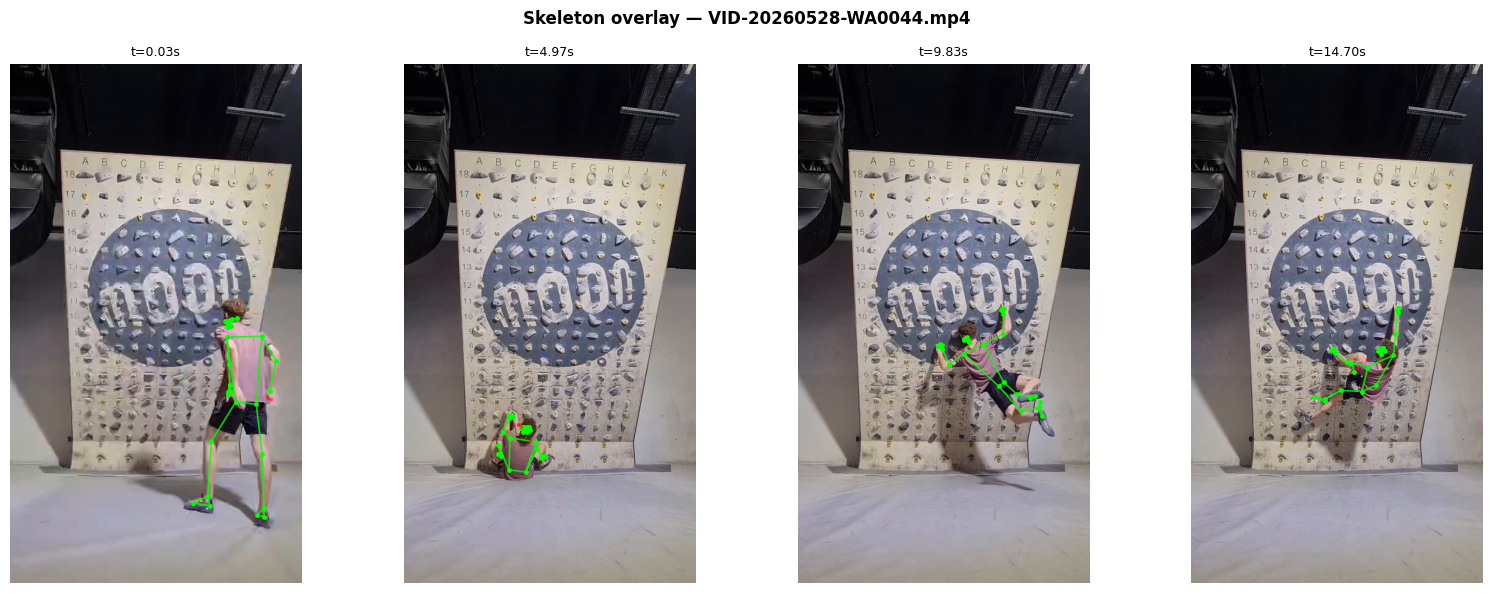

In [9]:
def draw_skeleton(ax, frame_kp: pd.DataFrame, frame: np.ndarray, min_vis: float = 0.3) -> None:
    """Overlay skeleton on a matplotlib Axes given a single-frame keypoints slice."""
    ax.imshow(frame)
    H, W = frame.shape[:2]

    # xy arrays indexed by landmark_id
    lm = frame_kp.sort_values('landmark_id')
    xs = lm['x'].values * W
    ys = lm['y'].values * H
    vs = lm['visibility'].values

    # Draw edges
    for s, e in POSE_CONNECTIONS:
        if vs[s] > min_vis and vs[e] > min_vis:
            ax.plot([xs[s], xs[e]], [ys[s], ys[e]],
                    color='lime', linewidth=1.2, alpha=0.8)

    # Draw joints, color by visibility
    visible = vs > min_vis
    ax.scatter(xs[visible], ys[visible],
               c='lime', s=12, zorder=5, linewidths=0)
    ax.scatter(xs[~visible], ys[~visible],
               c='red', s=6, zorder=5, linewidths=0, alpha=0.5)

    ax.axis('off')


# Pick 4 frames where pose was detected
detected_frames = detected[detected == 1].index.tolist()
print(f'{len(detected_frames)} frames with pose detected')

if detected_frames:
    step = max(1, len(detected_frames) // 4)
    showcase = detected_frames[::step][:4]
    showcase_set = set(showcase)

    showcase_frames = {}
    for fidx, ts, frame in iter_frames(VIDEO_PATH):
        if fidx in showcase_set:
            showcase_frames[fidx] = (ts, frame)
        if len(showcase_frames) == len(showcase_set):
            break

    fig, axes = plt.subplots(1, len(showcase), figsize=(4 * len(showcase), 6))
    if len(showcase) == 1:
        axes = [axes]
    for ax, fidx in zip(axes, showcase):
        ts, frame = showcase_frames[fidx]
        frame_kp = kp[kp['frame_idx'] == fidx]
        draw_skeleton(ax, frame_kp, frame)
        ax.set_title(f't={ts:.2f}s', fontsize=9)
    plt.suptitle(f'Skeleton overlay — {VIDEO_PATH.name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No pose detected in this clip — try a different video or lower min_detection_confidence.')

## 6. Joint trajectories over time

Normalized x/y coordinates of key joints across the clip.

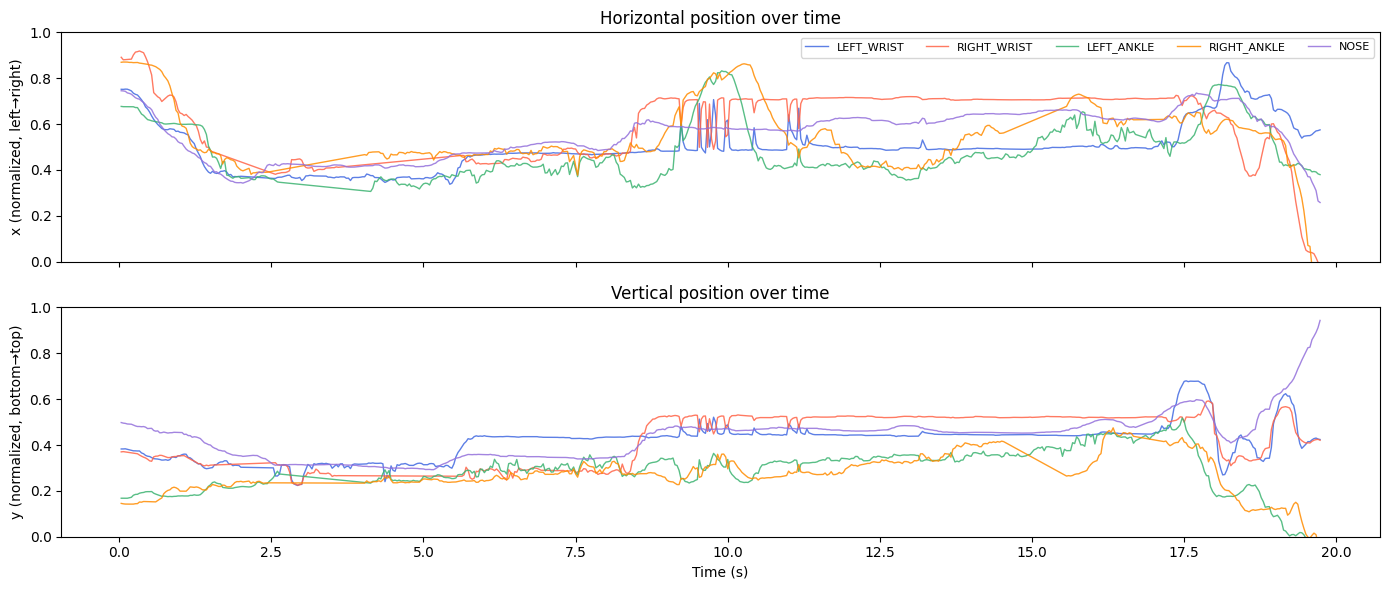

In [10]:
TRACKED_JOINTS = ['LEFT_WRIST', 'RIGHT_WRIST', 'LEFT_ANKLE', 'RIGHT_ANKLE', 'NOSE']
COLORS = ['royalblue', 'tomato', 'mediumseagreen', 'darkorange', 'mediumpurple']

# Only frames where pose was detected
kp_detected = kp[kp['frame_idx'].isin(detected_frames)].copy()
kp_detected['t'] = kp_detected['timestamp_ms'] / 1000.0

fig, (ax_x, ax_y) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for joint, color in zip(TRACKED_JOINTS, COLORS):
    jdf = kp_detected[kp_detected['landmark_name'] == joint]
    visible = jdf[jdf['visibility'] > 0.3]
    ax_x.plot(visible['t'], visible['x'], color=color, label=joint, linewidth=1.0, alpha=0.85)
    ax_y.plot(visible['t'], 1 - visible['y'], color=color, linewidth=1.0, alpha=0.85)  # flip y: 0=bottom

ax_x.set_ylabel('x (normalized, left→right)')
ax_x.set_title('Horizontal position over time')
ax_x.legend(ncol=len(TRACKED_JOINTS), fontsize=8, loc='upper right')
ax_x.set_ylim(0, 1)

ax_y.set_ylabel('y (normalized, bottom→top)')
ax_y.set_title('Vertical position over time')
ax_y.set_xlabel('Time (s)')
ax_y.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 7. Wrist speed (proxy for move activity)

Euclidean speed of the wrists in normalized coordinates per second. Spikes hint at dynamic moves.

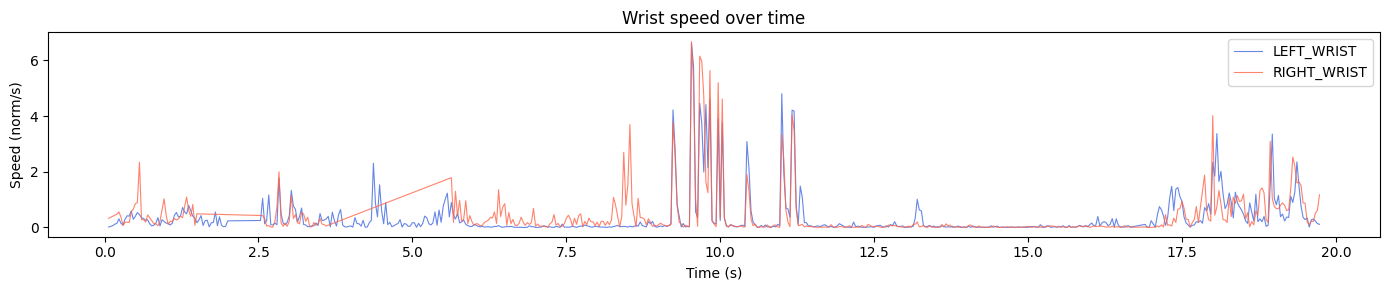

In [11]:
def joint_speed(kp_df: pd.DataFrame, joint: str, min_vis: float = 0.3) -> pd.Series:
    """Per-frame speed (normalized units/sec) for one joint."""
    jdf = (
        kp_df[kp_df['landmark_name'] == joint]
        .set_index('frame_idx')
        .sort_index()
    )
    good = jdf['visibility'] > min_vis
    t = jdf['timestamp_ms'] / 1000.0
    dx = jdf['x'].diff()
    dy = jdf['y'].diff()
    dt = t.diff().replace(0, np.nan)
    speed = np.sqrt(dx**2 + dy**2) / dt
    speed[~good] = np.nan
    return speed


fig, ax = plt.subplots(figsize=(14, 3))

for joint, color in [('LEFT_WRIST', 'royalblue'), ('RIGHT_WRIST', 'tomato')]:
    spd = joint_speed(kp, joint)
    ts_idx = kp[kp['landmark_name'] == joint].set_index('frame_idx')['timestamp_ms'] / 1000.0
    valid = ~spd.isna()
    ax.plot(ts_idx[valid], spd[valid], color=color, label=joint, linewidth=0.8, alpha=0.8)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Speed (norm/s)')
ax.set_title('Wrist speed over time')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Parquet on disk

Confirm the output file is there and report size.

In [12]:
size_kb = parquet_path.stat().st_size / 1024
print(f'Parquet file : {parquet_path}')
print(f'Size         : {size_kb:.1f} KB')
print(f'Rows         : {len(kp):,}  ({len(kp)//33} frames × 33 landmarks)')
print()
print('Numeric summary:')
kp[['x','y','z','visibility']].describe().round(3)

Parquet file : ../data/processed/VID-20260528-WA0044_keypoints.parquet
Size         : 455.1 KB
Rows         : 19,569  (593 frames × 33 landmarks)

Numeric summary:


,x,y,z,visibility
count,19338.000,19338.000,19338.000,19569.000
mean,0.537,0.614,-0.023,0.814
std,0.127,0.113,0.308,0.264
min,-0.154,0.032,-1.054,0.000
25%,0.438,0.538,-0.214,0.699
50%,0.520,0.622,-0.058,0.958
75%,0.633,0.693,0.142,0.999
max,0.934,1.170,0.861,1.000
